# Food Security in Africa and Kenya

---

### What is Food Security?

According to the Food and Agriculture Organization (FAO), food security exists when all people, at all times, have physical, social and economic access to sufficient, safe and nutritious food that meets their dietary needs for an active and healthy life.

Food security has four pillars:

- **Availability** — Is enough food being produced?
- **Access** — Can people physically reach the food?
- **Affordability** — Can people economically afford the food?
- **Utilization** — Is the food nutritious and safe to eat?

When any one of these pillars breaks down, food insecurity follows.

---

### The Problem

Millions of Africans face hunger every year. Yet food aid almost always arrives after people are already starving. This project uses data to answer three questions:

1. How bad is food insecurity across Africa and which countries are most affected?
2. Is Africa not producing enough food, or is the problem that people cannot afford it?
3. Zooming into Kenya — why are Kenyans food insecure and what needs to change?

---

### Data Sources

- FAO FAOSTAT — Food Security Indicators: https://www.fao.org/faostat/en/#data/FS
- FAO FAOSTAT — Food Production data: https://www.fao.org/faostat/en/#data/QCL
- World Bank — Poverty headcount ratio: https://data.worldbank.org/indicator/SI.POV.DDAY
- World Bank — Population data: https://data.worldbank.org/indicator/SP.POP.TOTL
- KNBS — Kenya Consumer Price Index: https://www.knbs.or.ke
- FEWS NET / KFSSG — Kenya county food insecurity reports

---
### Importing Libraries

In [102]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('OUTPUT', exist_ok=True)

---
### Loading the Datasets

In [103]:
food_security   = pd.read_csv('DATA/Food_security_Africa.csv')
food_production = pd.read_csv('DATA/Food_Production_Africa.csv')
poverty         = pd.read_csv('DATA/Poverty_Africa.csv',    skiprows=4)
population      = pd.read_csv('DATA/Population_Africa.csv', skiprows=4)

print(food_security.shape)
print(food_production.shape)
print(poverty.shape)
print(population.shape)

(13608, 15)
(3132, 15)
(266, 71)
(266, 71)


---
### Cleaning the Food Security Data

In [104]:
food_security_clean = food_security[['Area', 'Item', 'Year', 'Value']].copy()

items_we_need = [
    'Prevalence of severe food insecurity in the total population (percent) (3-year average)',
    'Prevalence of moderate or severe food insecurity in the total population (percent) (3-year average)'
]

food_security_clean = food_security_clean[food_security_clean['Item'].isin(items_we_need)]
food_security_clean = food_security_clean[
    food_security_clean['Year'].str[:4].astype(int) >= 2014
]

food_security_clean.columns = ['Country', 'Indicator', 'Year', 'Value']

food_security_clean['Indicator'] = food_security_clean['Indicator'].replace({
    'Prevalence of severe food insecurity in the total population (percent) (3-year average)': 'Severe Food Insecurity (%)',
    'Prevalence of moderate or severe food insecurity in the total population (percent) (3-year average)': 'Moderate or Severe Food Insecurity (%)'
})

food_security_clean = food_security_clean.dropna(subset=['Value'])
food_security_clean['Value']    = pd.to_numeric(food_security_clean['Value'], errors='coerce')
food_security_clean['Year_int'] = food_security_clean['Year'].str[:4].astype(int)

print(food_security_clean.shape)
food_security_clean.head()

(1620, 5)


,Country,Indicator,Year,Value,Year_int
0,Algeria,Severe Food Insecurity (%),2016-2018,11.4,2016
1,Algeria,Severe Food Insecurity (%),2016-2018,8.7,2016
2,Algeria,Severe Food Insecurity (%),2016-2018,14.1,2016
3,Algeria,Severe Food Insecurity (%),2017-2019,9.3,2017
4,Algeria,Severe Food Insecurity (%),2017-2019,7.0,2017


---
### Cleaning the Food Production Data

In [105]:
food_production_clean = food_production[
    food_production['Element'] == 'Production'
][['Area', 'Item', 'Year', 'Value']].copy()

food_production_clean = food_production_clean[food_production_clean['Year'] >= 2014]
food_production_clean.columns = ['Country', 'Crop', 'Year', 'Production (tonnes)']
food_production_clean = food_production_clean.dropna(subset=['Production (tonnes)'])

production_by_year = food_production_clean.groupby('Year')['Production (tonnes)'].sum().reset_index()

print(production_by_year.shape)
production_by_year.head()

(8, 2)


,Year,Production (tonnes)
0,2017,1.128135e+09
1,2018,1.180138e+09
2,2019,1.191135e+09
3,2020,1.226859e+09
4,2021,1.254389e+09


---
### Cleaning the Poverty Data

In [106]:
poverty = poverty.drop(columns=['Unnamed: 70'], errors='ignore')

year_cols     = [str(y) for y in range(2014, 2025)]
poverty_clean = poverty[['Country Name', 'Country Code'] + year_cols].copy()

# syntax - df.melt(id_vars, value_vars, var_name, value_name)
poverty_long = poverty_clean.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=year_cols,
    var_name='Year',
    value_name='Poverty Rate (%)'
)

poverty_long.columns = ['Country', 'Country Code', 'Year', 'Poverty Rate (%)']
poverty_long['Year'] = poverty_long['Year'].astype(int)
poverty_long         = poverty_long.dropna(subset=['Poverty Rate (%)'])

print(poverty_long.shape)
poverty_long.head()

(959, 4)


,Country,Country Code,Year,Poverty Rate (%)
5,Albania,ALB,2014,3.7
9,Argentina,ARG,2014,1.1
10,Armenia,ARM,2014,3.4
13,Australia,AUS,2014,0.6
14,Austria,AUT,2014,0.2


---
### Loading the Africa Map

In [107]:
url   = 'https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson'
world = gpd.read_file(url)

african_codes = [
    'DZA','AGO','BEN','BWA','BFA','BDI','CPV','CMR','CAF','TCD',
    'COM','COD','COG','CIV','DJI','EGY','GNQ','ERI','SWZ','ETH',
    'GAB','GMB','GHA','GIN','GNB','KEN','LSO','LBR','LBY','MDG',
    'MWI','MLI','MRT','MUS','MAR','MOZ','NAM','NER','NGA','RWA',
    'STP','SEN','SLE','SOM','ZAF','SSD','SDN','TZA','TGO','TUN',
    'UGA','ZMB','ZWE'
]

africa_map = world[world['ISO3166-1-Alpha-3'].isin(african_codes)].copy()

print(africa_map.shape)
africa_map.head()

(53, 4)


,name,ISO3166-1-Alpha-3,ISO3166-1-Alpha-2,geometry
13,Ethiopia,ETH,ET,"POLYGON ((34.0707 9.45459, 34.06689 9.53118, 3..."
14,South Sudan,SSD,SS,"POLYGON ((35.92084 4.61933, 35.85654 4.6196, 3..."
15,Somalia,SOM,SO,"POLYGON ((46.46696 6.53829, 46.48805 6.55864, ..."
16,Kenya,KEN,KE,"MULTIPOLYGON (((35.70585 4.61945, 35.70594 4.6..."
17,Malawi,MWI,MW,"MULTIPOLYGON (((34.96462 -11.57356, 34.65125 -..."


---
### Kenya County Food Insecurity Data

County level food insecurity data sourced from FEWS NET and Kenya Food Security Steering Group (KFSSG) reports.

In [108]:
kenya_county_data = pd.DataFrame({
    'County': [
        'Turkana', 'Marsabit', 'Mandera', 'Wajir', 'Garissa',
        'Tana River', 'Kilifi', 'Kwale', 'Taita-Taveta', 'Kajiado',
        'Narok', 'Samburu', 'Isiolo', 'West Pokot', 'Baringo',
        'Laikipia', 'Nakuru', 'Nairobi', 'Mombasa', 'Kisumu',
        'Siaya', 'Homa Bay', 'Migori', 'Kisii', 'Nyamira',
        'Kericho', 'Bomet', 'Nandi', 'Uasin Gishu', 'Trans-Nzoia',
        'Bungoma', 'Kakamega', 'Vihiga', 'Busia', 'Elgeyo-Marakwet',
        'Nyandarua', 'Nyeri', 'Kirinyaga', "Murang'a", 'Kiambu',
        'Meru', 'Tharaka-Nithi', 'Embu', 'Machakos', 'Makueni',
        'Kitui', 'Lamu'
    ],
    'Food_Insecurity': [
        82, 78, 80, 76, 72, 68, 61, 58, 45, 42,
        48, 74, 70, 72, 55, 38, 32, 28, 35, 40,
        45, 48, 44, 36, 34, 30, 32, 28, 25, 22,
        30, 33, 38, 40, 42, 25, 22, 20, 24, 18,
        22, 28, 24, 32, 55, 62, 50
    ]
})

kenya_county_data.head(10)

,County,Food_Insecurity
0,Turkana,82
1,Marsabit,78
2,Mandera,80
3,Wajir,76
4,Garissa,72
5,Tana River,68
6,Kilifi,61
7,Kwale,58
8,Taita-Taveta,45
9,Kajiado,42


---
## Part 1 — The Scale of Food Insecurity in Africa

Africa is home to over 1.4 billion people. More than half face moderate or severe food insecurity. The continent has seen the situation worsen every year since 2016. This section establishes the scale of the crisis and shows which countries are bearing the heaviest burden — including Kenya.

### Where Is Hunger Worst?

The map shows every African country colored by its food insecurity level. The deeper the red the more severe the crisis. This is the starting point — before we can solve the problem we need to see where it is.

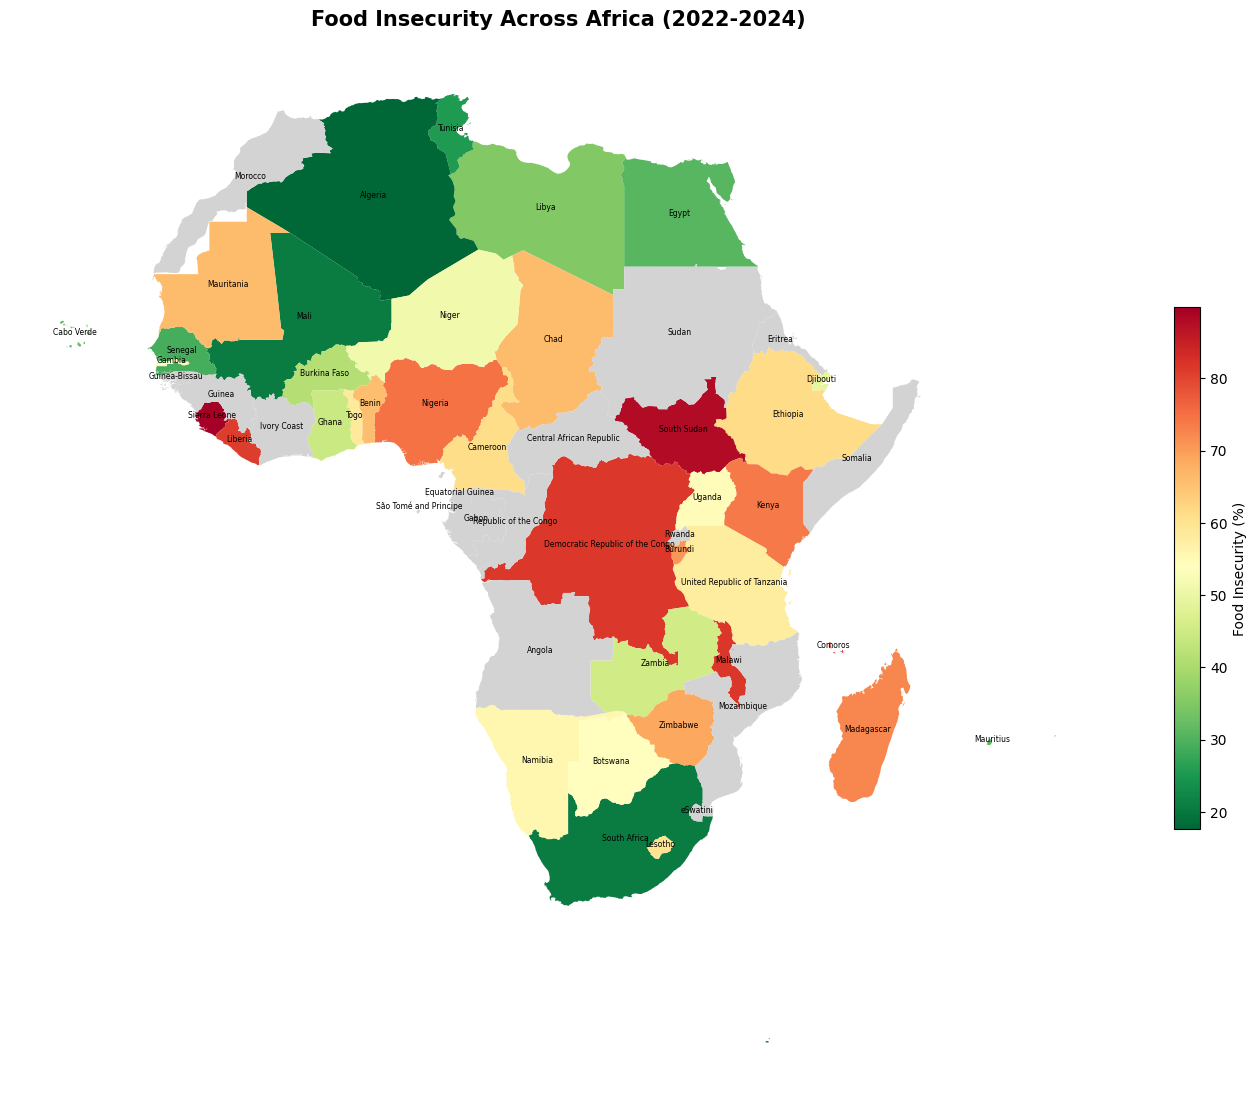

In [109]:
latest_year = food_security_clean['Year'].max()

latest_fs = food_security_clean[
    (food_security_clean['Year'] == latest_year) &
    (food_security_clean['Indicator'] == 'Moderate or Severe Food Insecurity (%)')
].groupby('Country')['Value'].mean().reset_index()

africa_fs_map = africa_map.merge(
    latest_fs, left_on='name', right_on='Country', how='left'
)

fig, ax = plt.subplots(1, 1, figsize=(14, 11))

africa_fs_map.plot(
    column='Value',
    cmap='RdYlGn_r',
    legend=True,
    legend_kwds={'label': 'Food Insecurity (%)', 'shrink': 0.5},
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
    ax=ax
)

for _, row in africa_fs_map.iterrows():
    ax.annotate(
        text=row['name'],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha='center', fontsize=5.5, color='black'
    )

ax.set_title(f'Food Insecurity Across Africa ({latest_year})', fontsize=15, fontweight='bold', pad=15)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('OUTPUT/africa_food_insecurity_map.png', dpi=150, bbox_inches='tight')
plt.show()

### Which Countries Are Most Affected?

The map gives us the geography — this chart gives us the numbers. Kenya ranks #8 in Africa despite being one of the continent's largest economies. That tells us something important: wealth alone does not solve hunger.

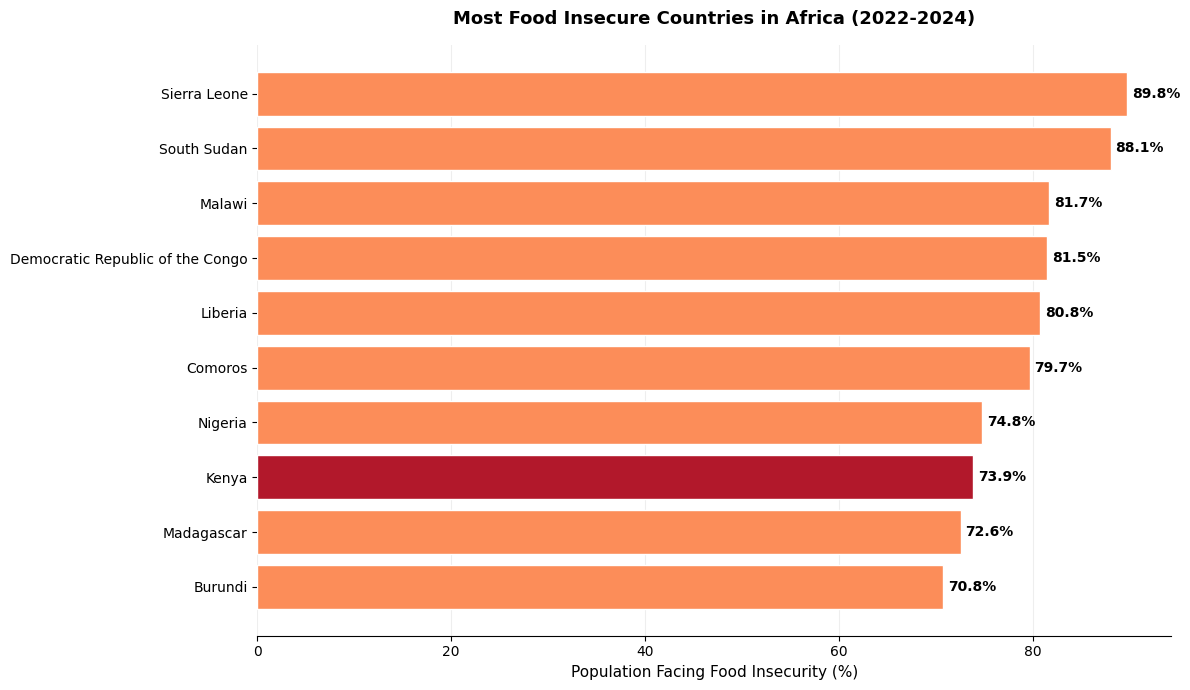

In [110]:
top10  = latest_fs.sort_values('Value', ascending=False).head(10)
colors = ['#b2182b' if c == 'Kenya' else '#fc8d59' for c in top10['Country']]

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(top10['Country'], top10['Value'], color=colors, edgecolor='white')

for bar, val in zip(bars, top10['Value']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Population Facing Food Insecurity (%)', fontsize=11)
ax.set_title(f'Most Food Insecure Countries in Africa ({latest_year})', fontsize=13, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.xaxis.grid(True, color='#eeeeee', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('OUTPUT/top10_food_insecure_africa.png', dpi=150, bbox_inches='tight')
plt.show()

### The Situation Is Getting Worse

This trend line answers the question: is Africa improving or going backward? The Africa average has been rising since 2016. Kenya's trajectory is even steeper — moving from 61% in 2016 to nearly 74% by 2024. This is not a temporary crisis. It is a sustained deterioration.

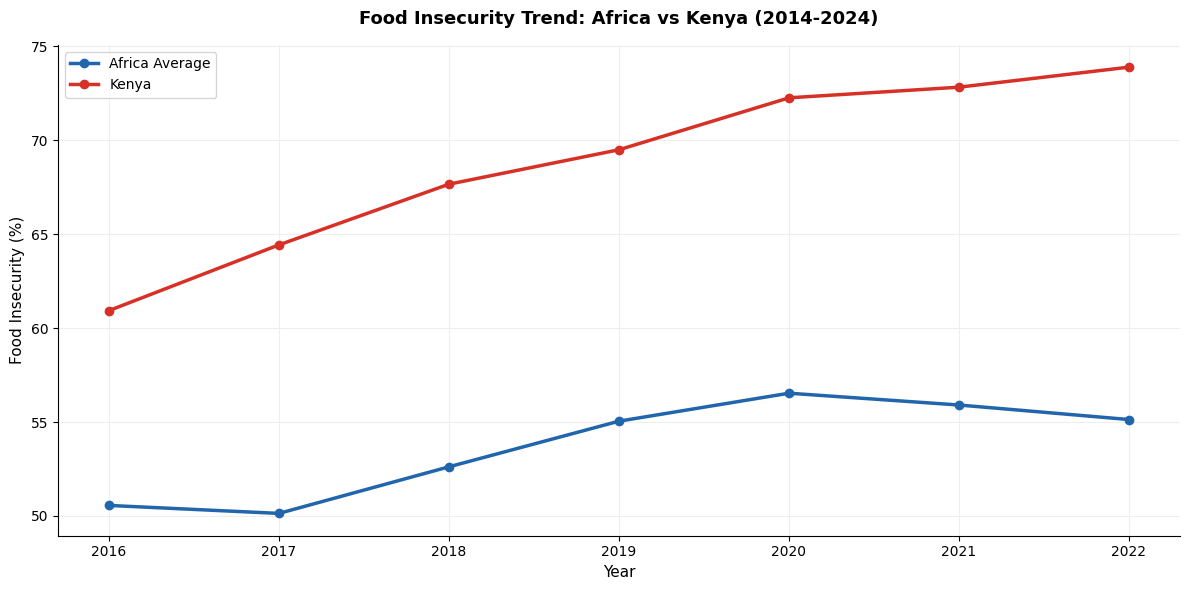

In [111]:
trend_data   = food_security_clean[
    food_security_clean['Indicator'] == 'Moderate or Severe Food Insecurity (%)'
].copy()

africa_trend = trend_data.groupby('Year_int')['Value'].mean().reset_index()
kenya_trend  = trend_data[trend_data['Country'] == 'Kenya'].groupby('Year_int')['Value'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(africa_trend['Year_int'], africa_trend['Value'],
        color='#2166ac', linewidth=2.5, marker='o', label='Africa Average')
ax.plot(kenya_trend['Year_int'], kenya_trend['Value'],
        color='#d73027', linewidth=2.5, marker='o', label='Kenya')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Food Insecurity (%)', fontsize=11)
ax.set_title('Food Insecurity Trend: Africa vs Kenya (2014-2024)', fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, color='#eeeeee', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('OUTPUT/africa_kenya_trend.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 2 — Is Africa Not Producing Enough Food?

A natural assumption is that hunger exists because not enough food is being grown. This chart tests that assumption directly. If production is rising while hunger is also rising, then production is not the problem — and we need to look elsewhere for the answer.

### Africa Is Producing More Food Every Year

Food production has grown consistently since 2014. This single chart settles the production question — the problem is not that Africa doesn't grow enough food. The problem is that the food being grown is not reaching the people who need it, and that people cannot afford to buy it.

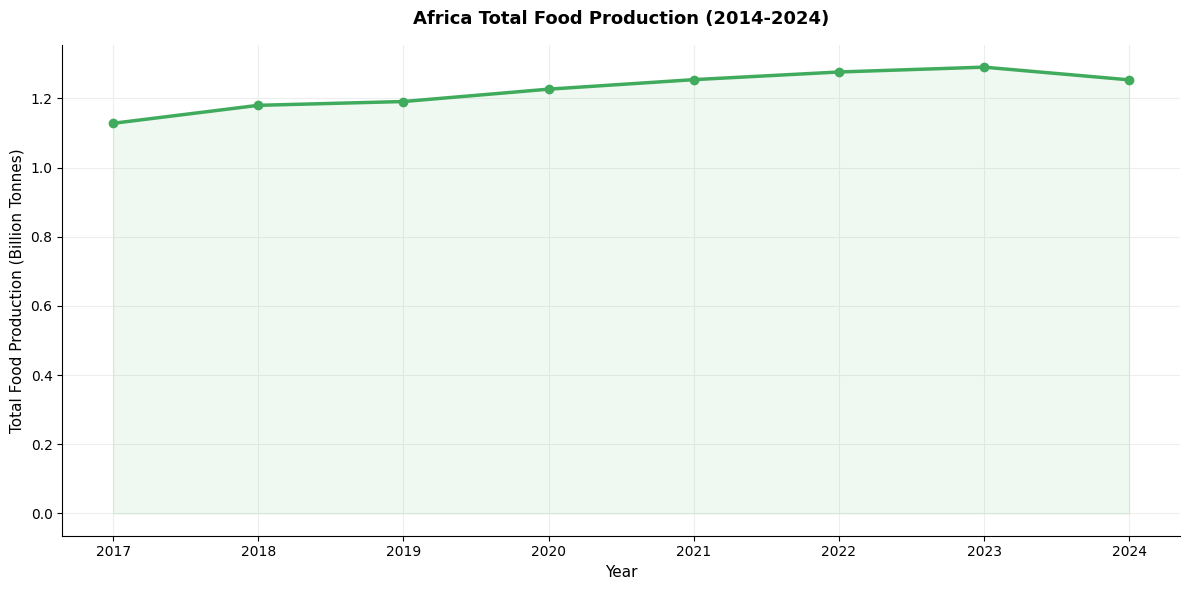

In [112]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(production_by_year['Year'],
        production_by_year['Production (tonnes)'] / 1e9,
        color='#41ab5d', linewidth=2.5, marker='o')
ax.fill_between(production_by_year['Year'],
                production_by_year['Production (tonnes)'] / 1e9,
                alpha=0.08, color='#41ab5d')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Total Food Production (Billion Tonnes)', fontsize=11)
ax.set_title('Africa Total Food Production (2014-2024)', fontsize=13, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, color='#eeeeee', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('OUTPUT/africa_production_trend.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 3 — Kenya Deep Dive

We now know Kenya is #8 in Africa for food insecurity and that the situation is getting worse. We also know production is not the cause. This section zooms into Kenya to answer two questions: **where** in Kenya are people most affected, and **why** is Kenya's situation worsening even as a major food-producing country?

### Filtering All Datasets for Kenya

In [113]:
kenya_food    = food_security_clean[food_security_clean['Country'] == 'Kenya'].copy()
kenya_poverty = poverty_long[poverty_long['Country'] == 'Kenya'].copy()

print(kenya_food.shape)
print(kenya_poverty)

(42, 5)
     Country Country Code  Year  Poverty Rate (%)
387    Kenya          KEN  2015              37.7
1717   Kenya          KEN  2020              44.4
1983   Kenya          KEN  2021              46.4
2249   Kenya          KEN  2022              45.5


### Where in Kenya Is Hunger Worst?

Food insecurity in Kenya is not spread evenly. The northern arid counties — Turkana, Mandera, Marsabit and Wajir — face rates above 75%. These are geographically remote areas far from food production centers, with poor road infrastructure and high poverty rates. Understanding this geography is essential to solving the problem.

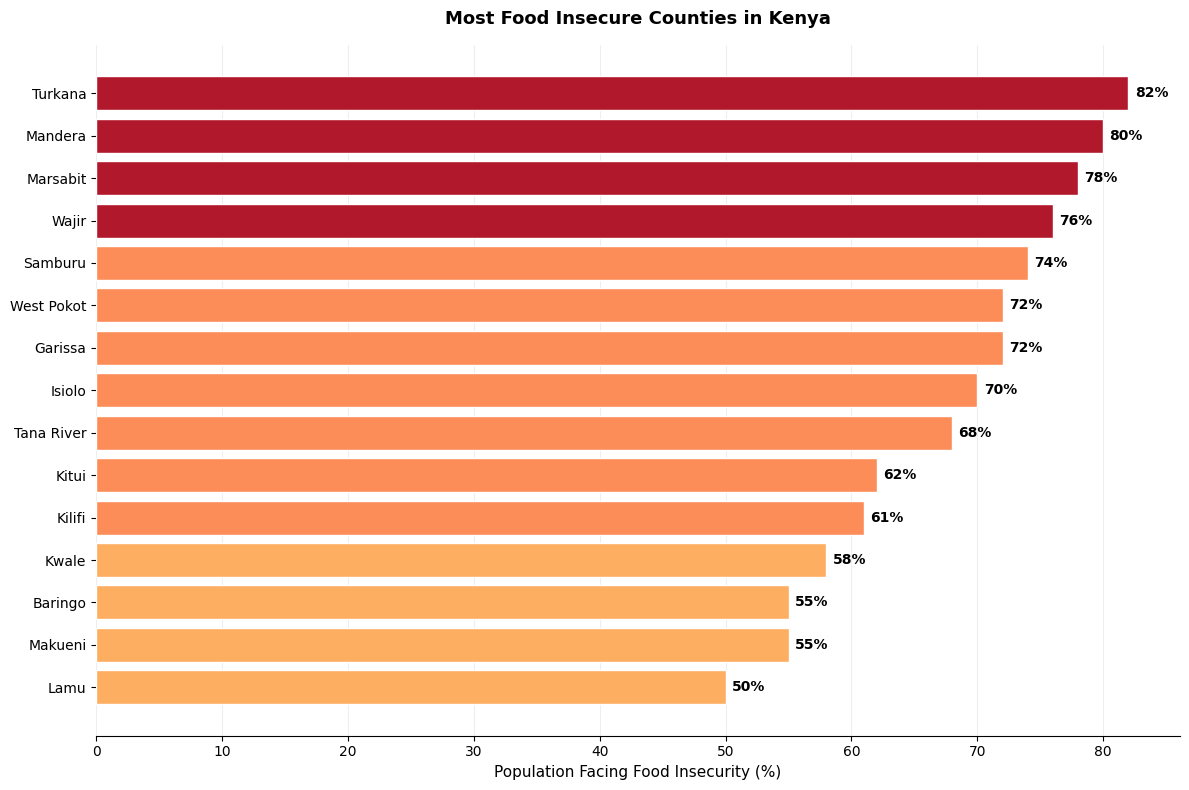

In [114]:
top15_counties  = kenya_county_data.sort_values('Food_Insecurity', ascending=False).head(15)
colors_counties = ['#b2182b' if v >= 75 else '#fc8d59' if v >= 60 else '#fdae61'
                   for v in top15_counties['Food_Insecurity']]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(top15_counties['County'], top15_counties['Food_Insecurity'],
               color=colors_counties, edgecolor='white')

for bar, val in zip(bars, top15_counties['Food_Insecurity']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Population Facing Food Insecurity (%)', fontsize=11)
ax.set_title('Most Food Insecure Counties in Kenya', fontsize=13, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.xaxis.grid(True, color='#eeeeee', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('OUTPUT/kenya_county_food_insecurity.png', dpi=150, bbox_inches='tight')
plt.show()

### Kenya Is Doing Worse Than Its Neighbors

Ethiopia and Uganda have been improving. Kenya has not. This chart shows that Kenya's worsening situation is not simply a regional trend — it is specific to Kenya and driven by factors within the country.

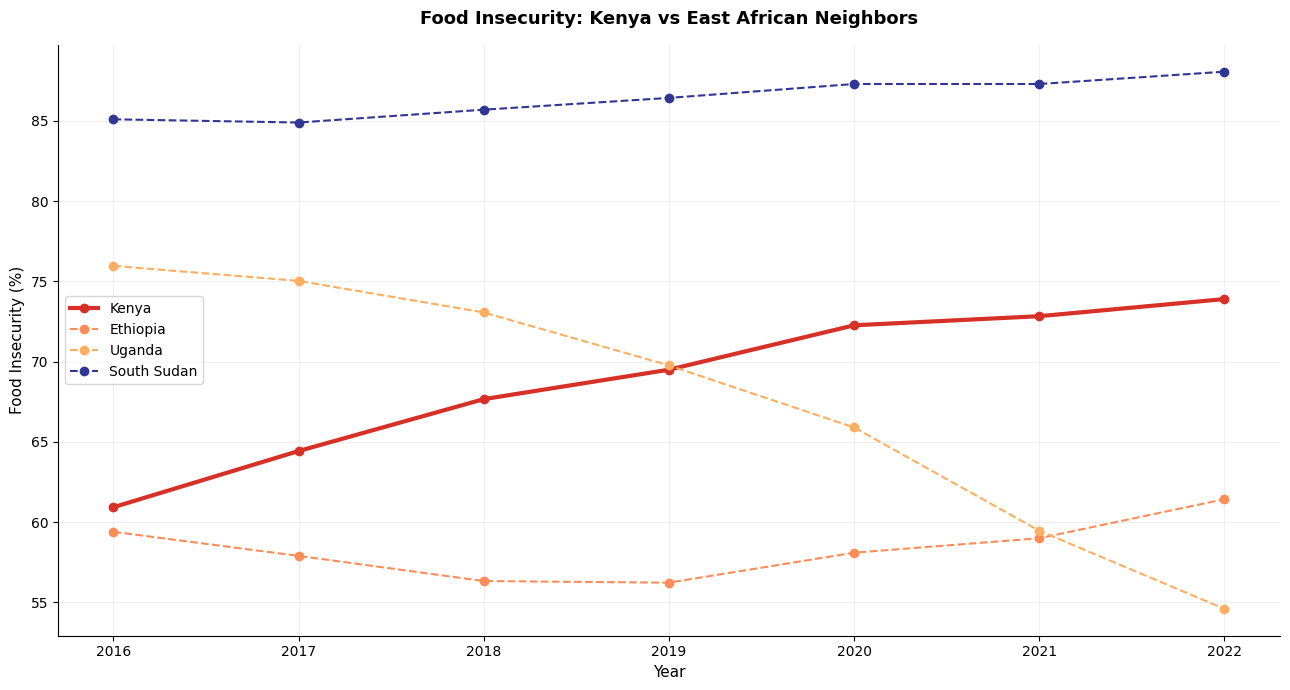

In [120]:
east_africa = ['Kenya', 'Ethiopia', 'Uganda', 'Tanzania', 'South Sudan']

ea_food = food_security_clean[
    (food_security_clean['Country'].isin(east_africa)) &
    (food_security_clean['Indicator'] == 'Moderate or Severe Food Insecurity (%)')
].copy()

colors_ea = ['#d73027', '#fc8d59', '#fdae61', '#4575b4', '#313695']

fig, ax = plt.subplots(figsize=(13, 7))

for i, country in enumerate(east_africa):
    country_data = ea_food[ea_food['Country'] == country].groupby('Year_int')['Value'].mean().reset_index()
    if len(country_data) > 1:
        ax.plot(country_data['Year_int'], country_data['Value'],
                color=colors_ea[i],
                linewidth=3 if country == 'Kenya' else 1.5,
                linestyle='-' if country == 'Kenya' else '--',
                marker='o', label=country)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Food Insecurity (%)', fontsize=11)
ax.set_title('Food Insecurity: Kenya vs East African Neighbors', fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, color='#eeeeee', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('OUTPUT/kenya_vs_east_africa.png', dpi=150, bbox_inches='tight')
plt.show()

### Poverty Is Rising Alongside Hunger

This chart directly tests whether poverty is driving Kenya's food insecurity. Both lines move in the same direction — as poverty rises, so does hunger. This confirms that affordability is the core problem. Food exists in Kenya but more and more people cannot afford to buy it.

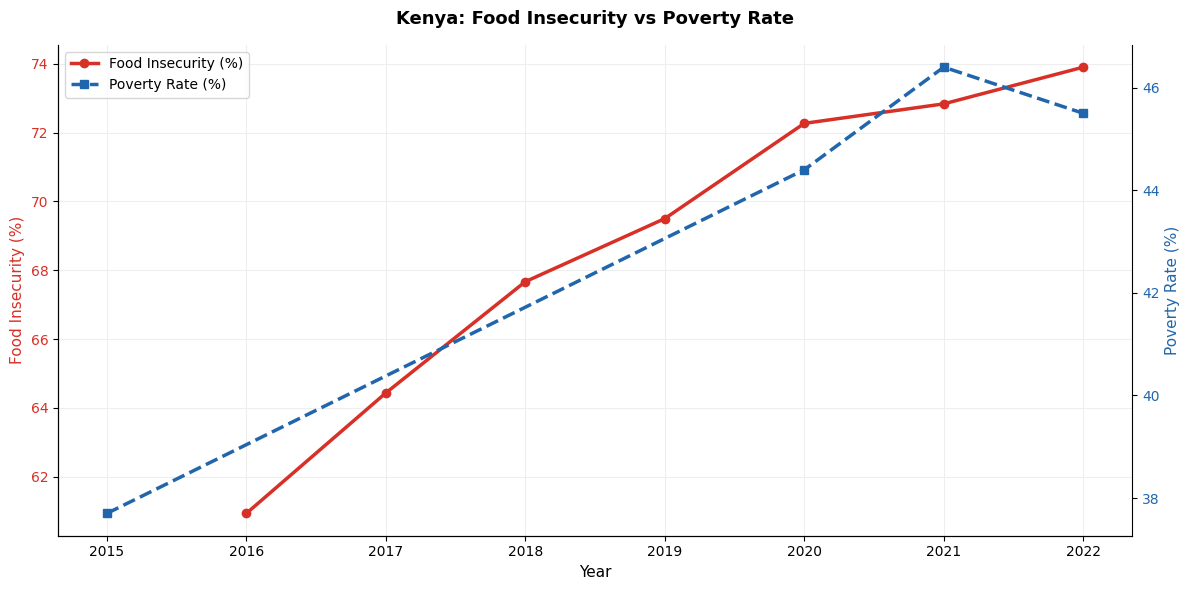

In [121]:
kenya_fs_trend = kenya_food[
    kenya_food['Indicator'] == 'Moderate or Severe Food Insecurity (%)'
].groupby('Year_int')['Value'].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(kenya_fs_trend['Year_int'], kenya_fs_trend['Value'],
         color='#d73027', linewidth=2.5, marker='o', label='Food Insecurity (%)')
ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Food Insecurity (%)', color='#d73027', fontsize=11)
ax1.tick_params(axis='y', labelcolor='#d73027')

ax2 = ax1.twinx()
ax2.plot(kenya_poverty['Year'], kenya_poverty['Poverty Rate (%)'],
         color='#2166ac', linewidth=2.5, marker='s', linestyle='--', label='Poverty Rate (%)')
ax2.set_ylabel('Poverty Rate (%)', color='#2166ac', fontsize=11)
ax2.tick_params(axis='y', labelcolor='#2166ac')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

ax1.set_title('Kenya: Food Insecurity vs Poverty Rate', fontsize=13, fontweight='bold', pad=15)
ax1.spines[['top', 'right']].set_visible(False)
ax2.spines[['top']].set_visible(False)
ax1.grid(True, color='#eeeeee', linewidth=0.8)
ax1.set_axisbelow(True)
plt.tight_layout()
plt.savefig('OUTPUT/kenya_food_vs_poverty.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 4 — Can the Average Kenyan Afford Food?

We have shown that poverty is rising and that it tracks food insecurity directly. Now we put a number to it. What does it actually look like for a typical Kenyan household trying to put food on the table every month?

### The Average Kenyan Household Cannot Cover Its Monthly Costs

The average Kenyan household earns around KES 18,000 per month. A basic food basket costs KES 12,500. Add non-food essentials and monthly expenses reach KES 20,500 — a deficit of KES 2,500 every single month. This is why hunger persists even when food is available in the market.

*Source: KNBS Economic Survey 2023, World Bank GNI per capita data.*

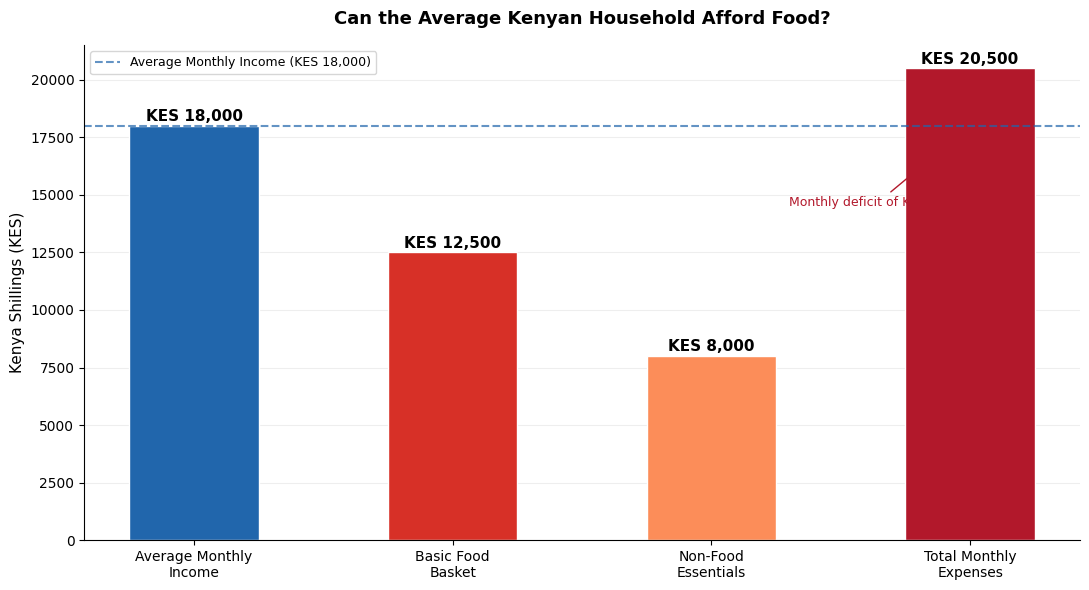

In [122]:
categories    = ['Average Monthly\nIncome', 'Basic Food\nBasket', 'Non-Food\nEssentials', 'Total Monthly\nExpenses']
values        = [18000, 12500, 8000, 20500]
colors_afford = ['#2166ac', '#d73027', '#fc8d59', '#b2182b']

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(categories, values, color=colors_afford, width=0.5, edgecolor='white')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'KES {val:,}', ha='center', fontsize=11, fontweight='bold')

ax.axhline(y=18000, color='#2166ac', linestyle='--', linewidth=1.5, alpha=0.7,
           label='Average Monthly Income (KES 18,000)')
ax.annotate('Monthly deficit of KES 2,500',
            xy=(3, 18000), xytext=(2.3, 14500),
            fontsize=9, color='#b2182b',
            arrowprops=dict(arrowstyle='->', color='#b2182b'))

ax.set_ylabel('Kenya Shillings (KES)', fontsize=11)
ax.set_title('Can the Average Kenyan Household Afford Food?', fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, color='#eeeeee', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('OUTPUT/kenya_household_affordability.png', dpi=150, bbox_inches='tight')
plt.show()

### Kenyans Spend Far More on Food Than People in Wealthier Countries

In the USA and Germany, households spend under 10% of their income on food. In Kenya the figure is around 45%. This means any rise in food prices — from drought, inflation or supply chain disruption — immediately pushes millions of Kenyan households into food insecurity because there is no financial buffer.

*Source: KNBS Household Income and Expenditure Survey, World Bank data.*

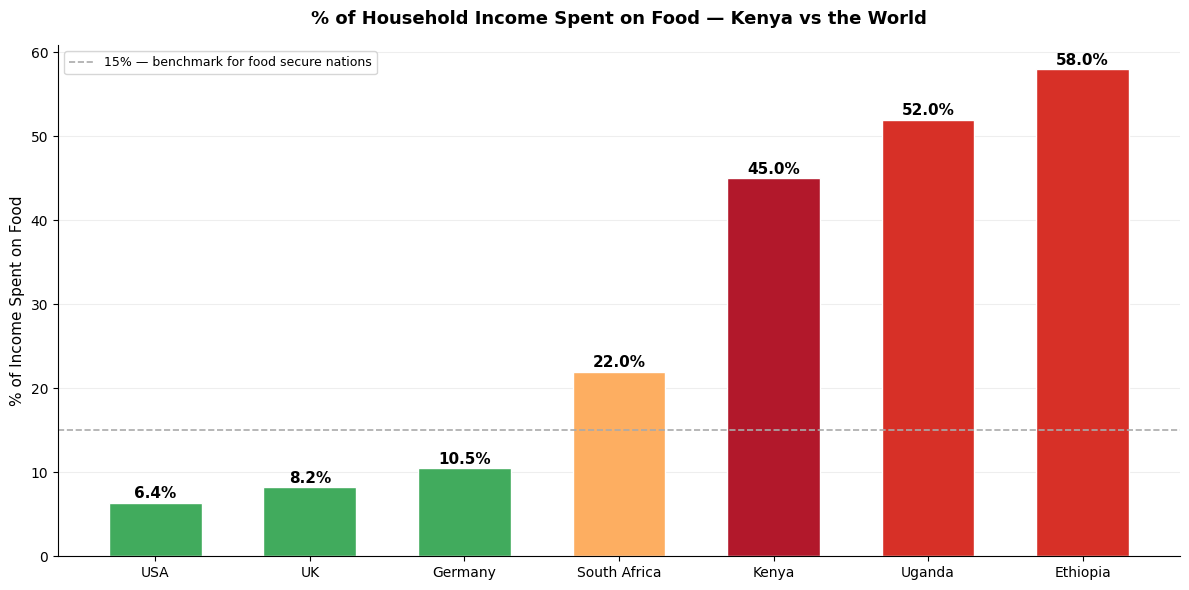

In [123]:
countries_spend = ['USA', 'UK', 'Germany', 'South Africa', 'Kenya', 'Uganda', 'Ethiopia']
food_spend_pct  = [6.4, 8.2, 10.5, 22.0, 45.0, 52.0, 58.0]
colors_spend    = ['#41ab5d' if p < 20 else '#fdae61' if p < 40 else '#d73027' for p in food_spend_pct]
colors_spend[4] = '#b2182b'

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(countries_spend, food_spend_pct, color=colors_spend, edgecolor='white', width=0.6)

for bar, val in zip(bars, food_spend_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=11, fontweight='bold')

ax.axhline(y=15, color='#aaaaaa', linestyle='--', linewidth=1.2, label='15% — benchmark for food secure nations')
ax.set_ylabel('% of Income Spent on Food', fontsize=11)
ax.set_title('% of Household Income Spent on Food — Kenya vs the World', fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, color='#eeeeee', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('OUTPUT/food_expenditure_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Conclusions

The data tells a clear and consistent story across all nine visualizations.

In [119]:
worst      = latest_fs.sort_values('Value', ascending=False).iloc[0]
kenya_rank = latest_fs.sort_values('Value', ascending=False).reset_index(drop=True)
kenya_pos  = kenya_rank[kenya_rank['Country'] == 'Kenya'].index[0] + 1
kenya_val  = kenya_rank[kenya_rank['Country'] == 'Kenya']['Value'].values[0]
africa_avg = latest_fs['Value'].mean()

if len(kenya_fs_trend) >= 2:
    change    = kenya_fs_trend.iloc[-1]['Value'] - kenya_fs_trend.iloc[0]['Value']
    direction = 'worsened' if change > 0 else 'improved'

print('=' * 60)
print('KEY FINDINGS')
print('=' * 60)
print(f'  Most food insecure country in Africa : {worst["Country"]} ({worst["Value"]:.1f}%)')
print(f'  Africa average food insecurity       : {africa_avg:.1f}%')
print(f'  Kenya ranks                          : #{kenya_pos} in Africa')
print(f'  Kenya food insecurity rate           : {kenya_val:.1f}%')
print(f'  Kenya trend                          : {direction} by {abs(change):.1f}% since 2016')
print(f'  Average monthly household deficit    : KES 2,500')
print(f'  % of income spent on food in Kenya   : ~45%')

print('\n' + '=' * 60)
print('CONCLUSIONS')
print('=' * 60)
print('''
1. The problem is NOT production.
   Africa is growing more food every year — and hunger
   is still rising. The food exists. People cannot access
   or afford it.

2. Poverty is the biggest driver.
   As poverty rises in Kenya, food insecurity rises with
   it in lockstep. The average household spends 45% of
   income on food and still runs a monthly deficit.

3. Geography matters.
   Turkana, Mandera, Marsabit and Wajir face rates above
   75%. These are remote, arid counties far from food
   production and markets.

4. Kenya is an outlier in its own region.
   Ethiopia and Uganda are improving. Kenya is not.
   The problem is specific to Kenya and requires
   Kenya-specific solutions.

5. What needs to change:
   - Reduce poverty through income support programs
   - Improve road and market access to arid counties
   - Support smallholder farmers in high-risk regions
   - Invest in drought-resistant crops and irrigation
''')

KEY FINDINGS
  Most food insecure country in Africa : Sierra Leone (89.8%)
  Africa average food insecurity       : 55.1%
  Kenya ranks                          : #8 in Africa
  Kenya food insecurity rate           : 73.9%
  Kenya trend                          : worsened by 13.0% since 2016
  Average monthly household deficit    : KES 2,500
  % of income spent on food in Kenya   : ~45%

CONCLUSIONS

1. The problem is NOT production.
   Africa is growing more food every year — and hunger
   is still rising. The food exists. People cannot access
   or afford it.

2. Poverty is the biggest driver.
   As poverty rises in Kenya, food insecurity rises with
   it in lockstep. The average household spends 45% of
   income on food and still runs a monthly deficit.

3. Geography matters.
   Turkana, Mandera, Marsabit and Wajir face rates above
   75%. These are remote, arid counties far from food
   production and markets.

4. Kenya is an outlier in its own region.
   Ethiopia and Uganda are im

---
### Saving All Clean Datasets

In [ ]:
food_security_clean.to_csv('OUTPUT/food_security_clean.csv', index=False)
poverty_long.to_csv('OUTPUT/poverty_clean.csv',              index=False)
kenya_food.to_csv('OUTPUT/kenya_food_security.csv',          index=False)
kenya_poverty.to_csv('OUTPUT/kenya_poverty.csv',             index=False)
kenya_county_data.to_csv('OUTPUT/kenya_county_food_insecurity.csv', index=False)

print('Done')
for f in sorted(os.listdir('OUTPUT')):
    print(f)